<a href="https://colab.research.google.com/github/mcaicedovezga/Estadistica-1-/blob/main/tarea_2_estadistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TAREA 2: MODELOS DE REGRESIÓN MÚLTIPLE

Integrantes



*   María José Caicedo Vezga 2231946
*   Angie Marieth Ortega Jaimes 2232446
*   Nixon Reynaldo Rojas Guevara 2231944





La base de datos SB11_20231.TXT comprende los resultados de la prueba Saber 11 del ICFES correspondiente al primer corte del año 2023. Evaluando las competencias de los estudiantes de último grado de educación media en Colombia en cinco áreas: Lectura Crítica, Matemáticas, Ciencias Naturales, Sociales y Ciudadanas, e Inglés. Por otra parte se encuentra la variable ESTU_INSE_INDIVIDUAL,que corresponde al Índice de Nivel Socioeconómico del estudiante dado por el ICFES a partir de variables del cuestionario socioeconómico (educación de los padres, ingresos, bienes del hogar, etc.).

Por medio de este trabajo se busca emplear modelos de regresión (lineal múltiple y red neuronal MLP) que permita imputar el nivel socioeconómico (ESTU_INSE_INDIVIDUAL) de los estudiantes a partir de sus puntajes en las cinco áreas examinadas.

In [ ]:

# LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr, spearmanr, kendalltau
from mpl_toolkits.mplot3d import Axes3D

In [ ]:

from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()
import pandas as pd
import io
datos_icfes = pd.read_csv(io.BytesIO(uploaded['SB11_20231.TXT']),
 delimiter='¬')

Saving SB11_20231.TXT to SB11_20231.TXT


/tmp/ipykernel_5069/3050728895.py:5: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  datos_icfes = pd.read_csv(io.BytesIO(uploaded['SB11_20231.TXT']),


Se carga la base de datos correspondiente a resultados del ICFES. Posteriormente se realiza una inspección inicial de las variables disponibles y de la estructura general del conjunto de datos.

In [ ]:
bites = io.BytesIO(uploaded['SB11_20231.TXT'])
icfes_sin_nan= pd.read_csv(bites, sep='¬', encoding="latin-1")
icfes_sin_nan.head(4)

/tmp/ipykernel_5069/2695722102.py:2: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  icfes_sin_nan= pd.read_csv(bites, sep='¬', encoding="latin-1")


,ESTU_TIPODOCUMENTOÂ,ESTU_NACIONALIDADÂ,ESTU_GENEROÂ,ESTU_FECHANACIMIENTOÂ,PERIODOÂ,ESTU_CONSECUTIVOÂ,ESTU_ESTUDIANTEÂ,ESTU_PAIS_RESIDEÂ,ESTU_DEPTO_RESIDEÂ,ESTU_COD_RESIDE_DEPTOÂ,...,PUNT_INGLESÂ,PERCENTIL_INGLESÂ,DESEMP_INGLESÂ,PUNT_GLOBALÂ,PERCENTIL_GLOBALÂ,ESTU_INSE_INDIVIDUALÂ,ESTU_NSE_INDIVIDUALÂ,ESTU_NSE_ESTABLECIMIENTOÂ,PERCENTIL_ESPECIAL_GLOBALÂ,ESTU_ESTADOINVESTIGACION
0,TIÂ,COLOMBIAÂ,FÂ,04/11/2005Â,20231Â,SB11202310019049Â,ESTUDIANTEÂ,COLOMBIAÂ,CUNDINAMARCAÂ,25Â,...,87Â,94Â,B+Â,422Â,100Â,67.5328144920732Â,4Â,4Â,100Â,PUBLICAR
1,TIÂ,COLOMBIAÂ,MÂ,08/04/2007Â,20231Â,SB11202310017318Â,ESTUDIANTEÂ,COLOMBIAÂ,VALLEÂ,76Â,...,Â,Â,Â,326Â,Â,47.2239721156478Â,2Â,3Â,100Â,PUBLICAR
2,TIÂ,COLOMBIAÂ,FÂ,26/05/2006Â,20231Â,SB11202310030916Â,ESTUDIANTEÂ,COLOMBIAÂ,VALLEÂ,76Â,...,Â,Â,Â,186Â,Â,67.6955192709169Â,4Â,3Â,40Â,PUBLICAR
3,CCÂ,COLOMBIAÂ,FÂ,24/05/2004Â,20231Â,SB11202310074169Â,ESTUDIANTEÂ,COLOMBIAÂ,VALLEÂ,76Â,...,58Â,43Â,A2Â,200Â,12Â,41.8631630741561Â,2Â,3Â,58Â,PUBLICAR


In [ ]:
 icfes_sin_nan = datos_icfes[
    (~datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna())
]

Se eliminan registros con valores faltantes en las variables de interés, con el fin de trabajar con información completa y evitar inconsistencias en los modelos predictivos.

In [ ]:
icfes_sin_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11853 entries, 0 to 12703
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ESTU_TIPODOCUMENTO             11853 non-null  object 
 1   ESTU_NACIONALIDAD              11853 non-null  object 
 2   ESTU_GENERO                    11853 non-null  object 
 3   ESTU_FECHANACIMIENTO           11853 non-null  object 
 4   PERIODO                        11853 non-null  int64  
 5   ESTU_CONSECUTIVO               11853 non-null  object 
 6   ESTU_ESTUDIANTE                11853 non-null  object 
 7   ESTU_PAIS_RESIDE               11853 non-null  object 
 8   ESTU_DEPTO_RESIDE              11853 non-null  object 
 9   ESTU_COD_RESIDE_DEPTO          11853 non-null  int64  
 10  ESTU_MCPIO_RESIDE              11853 non-null  object 
 11  ESTU_COD_RESIDE_MCPIO          11853 non-null  int64  
 12  ESTU_PRESENTACIONSABADO        11851 non-null  obje

In [ ]:
icfes_sin_nan.columns

Index(['ESTU_TIPODOCUMENTO', 'ESTU_NACIONALIDAD', 'ESTU_GENERO',
       'ESTU_FECHANACIMIENTO', 'PERIODO', 'ESTU_CONSECUTIVO',
       'ESTU_ESTUDIANTE', 'ESTU_PAIS_RESIDE', 'ESTU_DEPTO_RESIDE',
       'ESTU_COD_RESIDE_DEPTO', 'ESTU_MCPIO_RESIDE', 'ESTU_COD_RESIDE_MCPIO',
       'ESTU_PRESENTACIONSABADO', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR',
       'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONPADRE', 'FAMI_EDUCACIONMADRE',
       'FAMI_TRABAJOLABORPADRE', 'FAMI_TRABAJOLABORMADRE',
       'FAMI_TIENEINTERNET', 'FAMI_TIENESERVICIOTV', 'FAMI_TIENECOMPUTADOR',
       'FAMI_TIENELAVADORA', 'FAMI_TIENEHORNOMICROOGAS', 'FAMI_TIENEAUTOMOVIL',
       'FAMI_TIENEMOTOCICLETA', 'FAMI_TIENECONSOLAVIDEOJUEGOS',
       'FAMI_NUMLIBROS', 'FAMI_COMELECHEDERIVADOS',
       'FAMI_COMECARNEPESCADOHUEVO', 'FAMI_COMECEREALFRUTOSLEGUMBRE',
       'FAMI_SITUACIONECONOMICA', 'ESTU_DEDICACIONLECTURADIARIA',
       'ESTU_DEDICACIONINTERNET', 'ESTU_HORASSEMANATRABAJA',
       'ESTU_TIPOREMUNERACION', 'COLE_CODIGO_

In [ ]:
tabla_ESTU_INSE_INDIVIDUAL = icfes_sin_nan
tabla_regresion = tabla_ESTU_INSE_INDIVIDUAL[["PUNT_LECTURA_CRITICA", "PUNT_MATEMATICAS", "PUNT_C_NATURALES", "PUNT_SOCIALES_CIUDADANAS", "PUNT_INGLES" , "ESTU_INSE_INDIVIDUAL"]]
tabla_regresion.head(4)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,67.532814
3,45,41,41,27,58.0,41.863163
4,53,55,41,56,69.0,51.223795
5,63,38,60,59,45.0,57.690401


In [ ]:
En esta sección el código se asigna el conjunto de datos a una nueva variable.
Luego, se crea una tabla llamada tabla_regresion que contiene seis columnas específicas y,
finalmente, se muestran las primeras cuatro filas de dicha tabla.

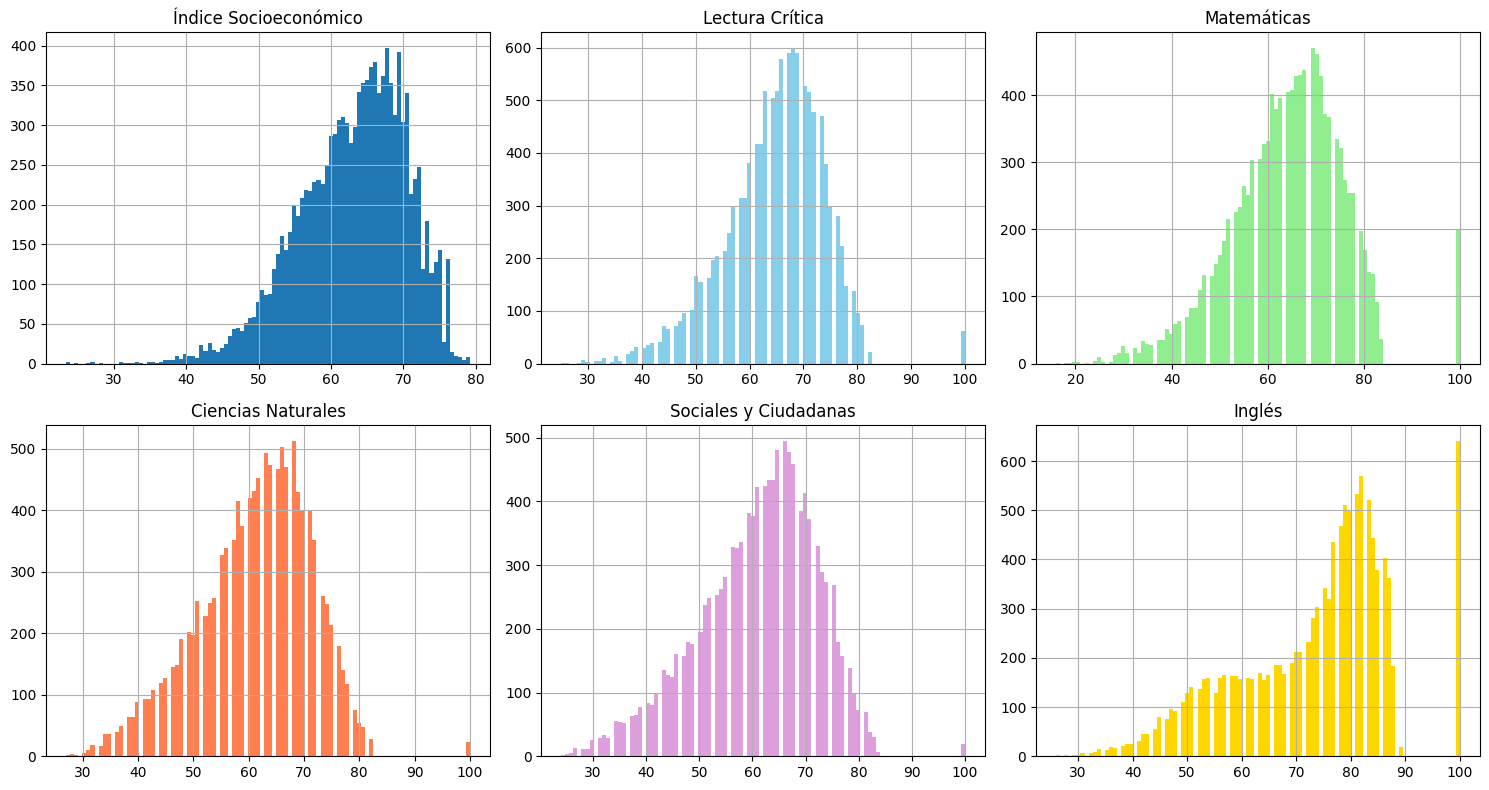

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15,8))

tabla_regresion1["ESTU_INSE_INDIVIDUAL"].hist(bins=100, ax=ax[0,0])
ax[0,0].set_title("Índice Socioeconómico")

tabla_regresion1["PUNT_LECTURA_CRITICA"].hist(bins=100, ax=ax[0,1], color="skyblue")
ax[0,1].set_title("Lectura Crítica")

tabla_regresion1["PUNT_MATEMATICAS"].hist(bins=100, ax=ax[0,2], color="lightgreen")
ax[0,2].set_title("Matemáticas")

tabla_regresion1["PUNT_C_NATURALES"].hist(bins=100, ax=ax[1,0], color="coral")
ax[1,0].set_title("Ciencias Naturales")

tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"].hist(bins=100, ax=ax[1,1], color="plum")
ax[1,1].set_title("Sociales y Ciudadanas")

tabla_regresion1["PUNT_INGLES"].hist(bins=100, ax=ax[1,2], color="gold")
ax[1,2].set_title("Inglés")

plt.tight_layout()
plt.show()


Los histogramas permiten visualizar la distribución de cada variable. En general, se observan concentraciones en rangos medios y ausencia de valores atípicos severos.

In [ ]:
tabla_regresion1 = tabla_regresion[
    (tabla_regresion['PUNT_C_NATURALES'] <= 100) &
    (tabla_regresion['PUNT_MATEMATICAS'] <= 100) &
    (tabla_regresion['PUNT_LECTURA_CRITICA'] <= 100) &
    (tabla_regresion['PUNT_SOCIALES_CIUDADANAS'] <= 100) &
    (tabla_regresion['PUNT_INGLES'] <= 100) &
    (tabla_regresion['ESTU_INSE_INDIVIDUAL'] <= 80)
]

tabla_regresion1.head(6)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,67.532814
3,45,41,41,27,58.0,41.863163
4,53,55,41,56,69.0,51.223795
5,63,38,60,59,45.0,57.690401
6,69,60,59,51,50.0,39.984838
7,57,68,74,61,52.0,50.613232


En esta sección del código se hace un filtrado de los datos de la tabla tabla_regresion. Se seleccionan aquellos registros cuyos puntajes en las pruebas de Lectura Crítica, Matemáticas, Ciencias Naturales, Sociales y Ciudadanas e Inglés sean menores o iguales a 100. Luego con esto se crea una nueva tabla llamada tabla_regresion1. Finalmente, se muestran las primeras seis filas de esta tabla.

In [ ]:
x = np.array(tabla_regresion1["PUNT_MATEMATICAS"]).reshape(-1, 1)
y = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]
trainx, testx, trainy, testy = train_test_split(x, y, test_size=0.2, random_state=0)
modelo_lineal0 = LinearRegression()
regresion0 = modelo_lineal0.fit(trainx, trainy)
pred_lineal0 = regresion0.predict(testx)

En esta parte del codigo se crea un modelo regresión lineal utilizando el puntaje de Matemáticas. Primero, los datos se analizan y luego se crea un conjunto de entrenamiento. Despues, se crea  un modelo de regresión lineal con los datos de entrenamiento. Finalmente, el modelo de regresion lineal se utiliza para realizar predicciones sobre el conjunto de datos de prueba.

# **Diagrama de dispersión**




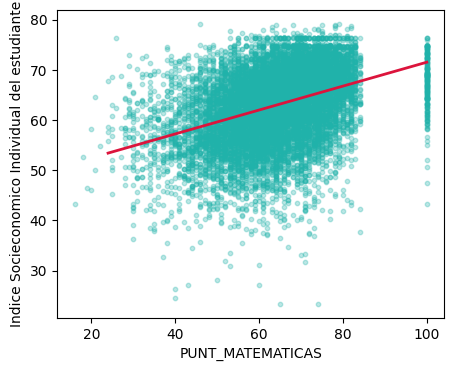

In [ ]:
plt.figure(figsize=(5, 4))
plt.scatter(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
            alpha=0.3, s=10, color='lightseagreen')
orden = np.argsort(testx.ravel())
plt.plot(testx.ravel()[orden], pred_lineal0[orden], linestyle='-', color='crimson', linewidth=2)
plt.xlabel("PUNT_MATEMATICAS")
plt.ylabel("Indice Socieconomico Individual del estudiante")
plt.show()  # Aqui se toman los datos de VALIDACIÓN (20%)

Se realiza una gráfica de los datos utilizando un diagrama de dispersión, donde el eje horizontal representa el puntaje en Matemáticas y el eje vertical el índice socioeconómico individual del estudiante.

In [ ]:
x0 = np.array(tabla_regresion1["PUNT_MATEMATICAS"]).reshape(-1, 1)
y0 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]
modelo_lineal01 = LinearRegression()
regresion01 = modelo_lineal01.fit(x0, y0)
pred_lineal01 = regresion01.predict(x0)

Se crea un modelo de regresión lineal utilizando el puntaje de Matemáticas y el índice socioeconómico individual como variables. Este modelo es entrenado con el objetivo de estimar la relación lineal entre ambas variables. Luego, se hacen predicciones del índice socioeconómico utilizando el modelo.

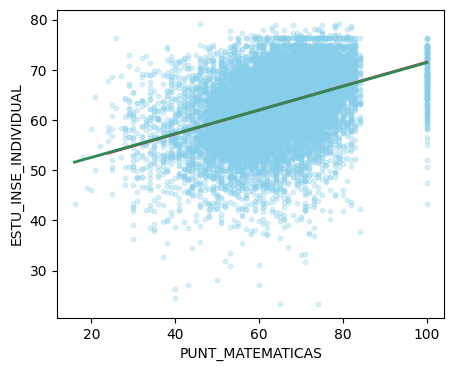

In [ ]:
orden2 = np.argsort(x0.ravel())
plt.figure(figsize=(5, 4))
plt.scatter(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
            alpha=0.3, s=10, color='skyblue')
plt.plot(testx.ravel()[orden], pred_lineal0[orden], linestyle='-', color='crimson', linewidth=2)
plt.plot(x0.ravel()[orden2], pred_lineal01[orden2], linestyle='-', color='seagreen', linewidth=2)
plt.xlabel("PUNT_MATEMATICAS")
plt.ylabel("ESTU_INSE_INDIVIDUAL")
plt.show() # Aqui tomamos TODOS los datos (100%)

Se genera una gráfica mediante el diagrama de dispersión mostrando la relación entre el puntaje en Matemáticas y el índice socioeconómico individual de los estudiantes. Superponiendo dos líneas de regresión lineal: la primera corresponde al modelo obtenido utilizando los datos de validación (20%), mientras que la segunda representa el modelo ajustado utilizando la totalidad de los datos disponibles (100%). La cual permite observar las diferencias entre ambos ajustes y analizar cómo varia la estimación de la relación entre las variables al utilizar diferentes conjuntos de datos para el entrenamiento del modelo.

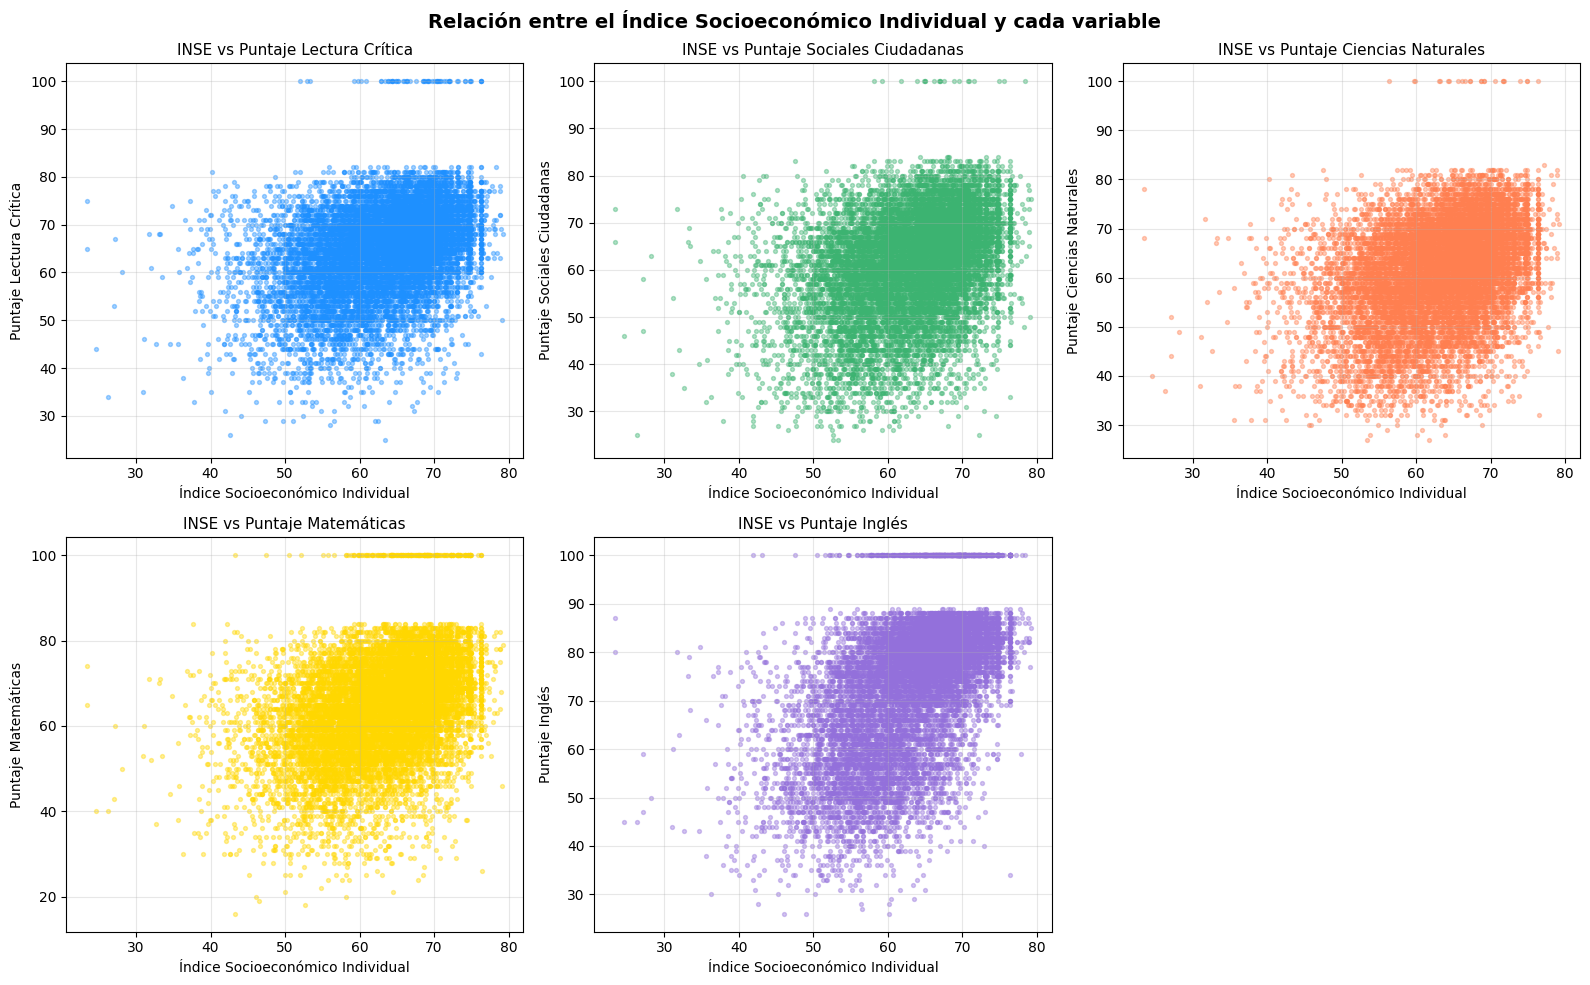

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Relación entre el Índice Socioeconómico Individual y cada variable",
             fontsize=14, fontweight='bold')

variables = [
    ("PUNT_LECTURA_CRITICA",    "Puntaje Lectura Crítica",    "dodgerblue"),
    ("PUNT_SOCIALES_CIUDADANAS","Puntaje Sociales Ciudadanas", "mediumseagreen"),
    ("PUNT_C_NATURALES",        "Puntaje Ciencias Naturales",  "coral"),
    ("PUNT_MATEMATICAS",        "Puntaje Matemáticas",         "gold"),
    ("PUNT_INGLES",             "Puntaje Inglés",              "mediumpurple"),
]

for ax, (var, label, color) in zip(axes.ravel(), variables):
    ax.scatter(
        tabla_regresion1["ESTU_INSE_INDIVIDUAL"],
        tabla_regresion1[var],
        color=color, alpha=0.4, s=8
    )
    ax.set_xlabel("Índice Socioeconómico Individual", fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"INSE vs {label}", fontsize=11)
    ax.grid(alpha=0.3)

# Ocultar el sexto panel que queda vacío
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

Se realiza el diagrama de dispersión de las otras variables en comparacion con el índice socioeconomico individual.

# **Selección por coeficiente de determinación (R²)**

Usando el método de exclusión ajustamos el modelo de regresión lineal múltiple completo y luego lo reajustamos quitando una variable a la vez. Si al quitar la variable el R² tiene una variación considerable, esa variable sera explicativa.

In [ ]:


X = tabla_regresion1.drop(["ESTU_INSE_INDIVIDUAL"], axis=1)
Y = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=0)
trainX.head(5)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
143,57,60,52,54,75.0
3114,67,69,65,65,79.0
7299,66,68,60,62,73.0
5895,69,65,62,66,100.0
7118,77,100,80,77,100.0


In [ ]:
modelo_lineal = LinearRegression()
regresion = modelo_lineal.fit(trainX, trainY)
r2_lineal= regresion.score(testX, testY)
print("R² :", r2_lineal)

R² : 0.3081968646144112


In [ ]:

X1 = tabla_regresion1[['PUNT_LECTURA_CRITICA',
                       'PUNT_C_NATURALES',
                       'PUNT_SOCIALES_CIUDADANAS',
                       'PUNT_INGLES']]

Y1 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train1X, test1X, train1Y, test1Y = train_test_split(
    X1, Y1,
    test_size = 0.2,
    random_state = 0
)

train1X.head(4)

,PUNT_LECTURA_CRITICA,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
143,57,52,54,75.0
3114,67,65,65,79.0
7299,66,60,62,73.0
5895,69,62,66,100.0


In [ ]:

modelo_lineal1 = LinearRegression()
regresion1 = modelo_lineal1.fit(train1X, train1Y)
r2_lineal1 = regresion1.score(test1X, test1Y)
print("R² Nodelo 1 :", r2_lineal1)

R² Nodelo 1 : 0.3091639949914916


In [ ]:

X2 = tabla_regresion1[['PUNT_MATEMATICAS',
                       'PUNT_C_NATURALES',
                       'PUNT_SOCIALES_CIUDADANAS',
                       'PUNT_INGLES']]

Y2 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train2X, test2X, train2Y, test2Y = train_test_split(
    X2, Y2,
    test_size = 0.2,
    random_state = 0
)
modelo_lineal2 = LinearRegression()
regresion2 = modelo_lineal2.fit(train2X, train2Y)
r2_lineal2 = regresion2.score(test2X, test2Y)
print("R² Nodelo :", r2_lineal2)


R² Nodelo : 0.30719150369119463


In [ ]:
X3= tabla_regresion1[['PUNT_MATEMATICAS',
                       'PUNT_LECTURA_CRITICA',
                       'PUNT_C_NATURALES',
                       'PUNT_SOCIALES_CIUDADANAS']]

Y3 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train3X, test3X, train3Y, test3Y = train_test_split(
    X3, Y3,
    test_size = 0.2,
    random_state = 0
)
modelo_lineal3 = LinearRegression()
regresion3 = modelo_lineal3.fit(train3X, train3Y)
r2_lineal3 = regresion3.score(test3X, test3Y)
print("R² Nodelo 3 :", r2_lineal3)

R² Nodelo 3 : 0.1605263009386998


las variables cuya exclusión produce mayor caída de R² son las más explicativas. En nuestro caso son PUNT_INGLES y PUNT_LECTURA_CRITICA.

# **`Regresión lineal completa`**

Definiendo las variables del modelo. La matriz XY contiene las variables explicativas seleccionadas anteriormente (PUNT_LECTURA_CRITICA y PUNT_INGLES), mientras que Z corresponde a la variable respuesta ESTU_INSE_INDIVIDUAL.

Se divide el conjunto de datos en dos partes: un conjunto de entrenamiento (80%) y un conjunto de prueba (20%), utilizando la función train_test_split. Esta separación permite entrenar el modelo con una parte de los datos y evaluar su desempeño con datos no utilizados durante el entrenamiento, garantizando así una mejor validación del modelo.

In [ ]:
XY, Z = tabla_regresion1[["PUNT_INGLES", "PUNT_LECTURA_CRITICA"]], tabla_regresion1["ESTU_INSE_INDIVIDUAL"]
trainXY, testXY, trainZ, testZ = train_test_split(XY, Z, test_size=0.2, random_state=0)
trainXY.head(4)

,PUNT_INGLES,PUNT_LECTURA_CRITICA
143,75.0,57
3114,79.0,67
7299,73.0,66
5895,100.0,69


In [ ]:
modelo1 = LinearRegression()
modelo1.fit(trainXY, trainZ)

LinearRegression()

In [ ]:
modelo1.score(testXY, testZ)

0.30793521819855896

In [ ]:
array = modelo1.coef_
array

array([0.29204812, 0.00268171])

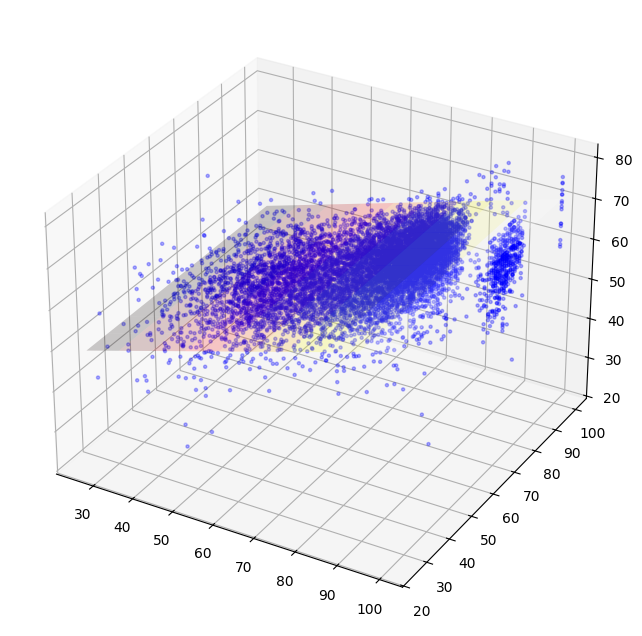

In [ ]:
fig = plt.figure(figsize=((10,8)))
ax = fig.add_subplot(projection='3d')
xx, yy = np.meshgrid(
    np.linspace(tabla_regresion1["PUNT_INGLES"].min(),
                tabla_regresion1["PUNT_INGLES"].max(), num=10),
    np.linspace(tabla_regresion1["PUNT_LECTURA_CRITICA"].min(),
                tabla_regresion1["PUNT_LECTURA_CRITICA"].max(), num=10)
)
plano_reg = array[0]*xx + array[1]*yy + modelo1.intercept_
ax.plot_surface(xx, yy, plano_reg, alpha=0.2, cmap='hot')
ax.scatter(trainXY["PUNT_INGLES"], trainXY["PUNT_LECTURA_CRITICA"], trainZ, c='blue', s=5, alpha=0.3)


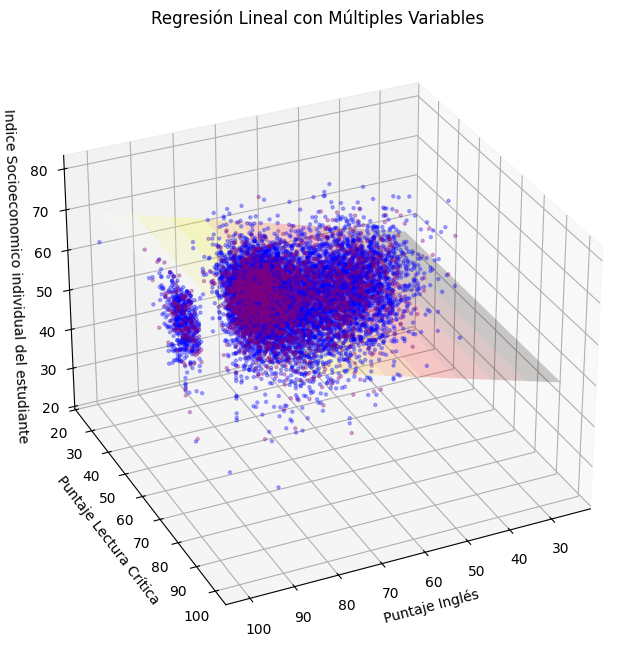

In [ ]:
fig = plt.figure(figsize=((10,8)))
ax = fig.add_subplot(projection='3d')
xx, yy = np.meshgrid(
    np.linspace(tabla_regresion1["PUNT_INGLES"].min(),
                tabla_regresion1["PUNT_INGLES"].max(), num=10),
    np.linspace(tabla_regresion1["PUNT_LECTURA_CRITICA"].min(),
                tabla_regresion1["PUNT_LECTURA_CRITICA"].max(), num=10)
)
plano_reg = array[0]*xx + array[1]*yy + modelo1.intercept_
ax.plot_surface(xx, yy, plano_reg, alpha=0.2, cmap='hot')
ax.scatter(trainXY["PUNT_INGLES"], trainXY["PUNT_LECTURA_CRITICA"], trainZ, c='blue', s=5, alpha=0.3)
ax.scatter(testXY["PUNT_INGLES"], testXY["PUNT_LECTURA_CRITICA"], testZ, c='purple', s=5, alpha=0.3)
ax.view_init(elev=30., azim=65)
ax.set_xlabel('Puntaje Inglés')
ax.set_ylabel('Puntaje Lectura Crítica')
ax.set_zlabel('Indice Socioeconomico individual del estudiante')
ax.set_title('Regresión Lineal con Múltiples Variables')
plt.show()

Dado que el coeficiente de determinación obtenido fue del 29%, el modelo no presenta un ajuste adecuado, por lo que es necesario plantear una nueva especificación de regresión (idealmente, un buen modelo debería alcanzar valores cercanos o superiores al 90%).

El gráfico anterior muestra la relación entre los puntajes en Inglés, Lectura Crítica y el nivel socioeconómico del estudiante. En él se aprecia que la mayoría de las observaciones se concentran en rangos intermedios, aunque con cierta variabilidad.

En consecuencia, se identifica una relación positiva de carácter moderado: a medida que aumentan los puntajes académicos, el nivel socioeconómico tiende a incrementarse ligeramente. No obstante, la dispersión de los datos sugiere que dicha relación no es lo suficientemente fuerte.

# **Red neuronal**

In [ ]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(100, 100,100,100,100,100), max_iter=500, random_state=0, activation = "relu", solver = "adam", learning_rate = "invscaling")
mlp_reg.fit(trainX, trainY)

MLPRegressor(hidden_layer_sizes=(100, 100, 100, 100, 100, 100),
             learning_rate='invscaling', max_iter=500, random_state=0)

Se utiliza un modelo de red neuronal multicapa para elaborar una tarea de regresión. Está compuesto por seis capas ocultas, cada una con 100 neuronas, y utiliza la función de activación ReLU. Para el proceso de optimización se emplea el algoritmo Adam, con un máximo de 500 iteraciones de entrenamiento. Siendo entrenado usando los datos del conjunto de entrenamiento con el objetivo de aprender la relación entre las variables y generar posteriormente predicciones sobre el índice socioeconómico individual.

In [ ]:
mlp_reg.score(testX, testY)

0.31100800090317426

El modelo de perceptrón multicapa obtuvo un R² = 0.311, superando levemente
al modelo de regresión lineal múltiple (R² = 0.308). Aunque la mejora es pequeña,
confirma que existen relaciones ligeramente no lineales entre los puntajes
de las pruebas y el índice socioeconómico.

Un R² de 0.31 indica que los puntajes académicos explican aproximadamente
el 31% de la variabilidad del nivel socioeconómico. El 69% restante corresponde
a factores no capturados en este modelo, como el estrato de vivienda,
la educación de los padres o el acceso a bienes del hogar.

In [ ]:
  X.head(4)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
0,100,83,77,77,87.0
3,45,41,41,27,58.0
4,53,55,41,56,69.0
5,63,38,60,59,45.0


In [ ]:
no_obs = np.array([[60, 70,85,90,52]])

print('Se espera que el Indice socioeconomico indivual del estudiante sea de', mlp_reg.predict(no_obs),
      'bajo el perceptrón multicapa y',
      modelo_lineal.predict(no_obs),
      'bajo el modelo de regresión lineal múltiple.')

Se espera que el Indice socioeconomico indivual del estudiante sea de [70.60296368] bajo el perceptrón multicapa y [57.18554855] bajo el modelo de regresión lineal múltiple.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Para un estudiante con puntajes:
- Lectura Crítica: 60, Matemáticas: 70, C. Naturales: 85, Sociales: 90, Inglés: 52

El MLP predice un INSE de 70.60 y la regresión lineal de 57.19.
La diferencia entre modelos refleja que el MLP captura mejor las interacciones
no lineales entre variables. Este perfil corresponde a un estudiante con
fortaleza en ciencias pero bajo desempeño en inglés, lo cual según el modelo
lo sitúa en un nivel socioeconómico medio-alto.

In [ ]:

# Matemáticas vs Índice Socioeconómico
pearson_corr = np.corrcoef(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr, _ = spearmanr(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr, _ = kendalltau(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

# Lectura Crítica vs Índice Socioeconómico
pearson_corr1 = np.corrcoef(tabla_regresion1["PUNT_LECTURA_CRITICA"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr1, _ = spearmanr(tabla_regresion1["PUNT_LECTURA_CRITICA"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr1, _ = kendalltau(tabla_regresion1["PUNT_LECTURA_CRITICA"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

# Ciencias Naturales vs Índice Socioeconómico
pearson_corr2 = np.corrcoef(tabla_regresion1["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr2, _ = spearmanr(tabla_regresion1["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr2, _ = kendalltau(tabla_regresion1["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

# Sociales y Ciudadanas vs Índice Socioeconómico
pearson_corr3 = np.corrcoef(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr3, _ = spearmanr(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr3, _ = kendalltau(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

# Inglés vs Índice Socioeconómico
pearson_corr4 = np.corrcoef(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0,1]
spearman_corr4, _ = spearmanr(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr4, _ = kendalltau(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

print("Los coeficientes de correlación de Pearson, Spearman y Kendall son respectivamente:")
print(f"Matemáticas: {pearson_corr}, {spearman_corr}, {kendall_corr}")
print(f"Lectura Crítica: {pearson_corr1}, {spearman_corr1}, {kendall_corr1}")
print(f"Ciencias Naturales: {pearson_corr2}, {spearman_corr2}, {kendall_corr2}")
print(f"Sociales y Ciudadanas: {pearson_corr3}, {spearman_corr3}, {kendall_corr3}")
print(f"Inglés: {pearson_corr4}, {spearman_corr4}, {kendall_corr4}")

Los coeficientes de correlación de Pearson, Spearman y Kendall son respectivamente:
Matemáticas: 0.37683736133080836, 0.39400899187464034, 0.27113110155972353
Lectura Crítica: 0.3548249041293775, 0.357601630521943, 0.24638305472022304
Ciencias Naturales: 0.35988523658908733, 0.36473331372387097, 0.2505203000174778
Sociales y Ciudadanas: 0.357710332535216, 0.3627552242779997, 0.24907781368459858
Inglés: 0.5511896092082889, 0.5656611211298977, 0.3957316498242702


Los tres coeficientes (Pearson, Spearman y Kendall) coinciden en que Inglés
es la variable con mayor correlación con el índice socioeconómico individual
(Pearson ≈ 0.55), lo que indica una relación moderada positiva: estudiantes con
mayor nivel socioeconómico tienden a obtener mejores puntajes en inglés.
Esto es consistente con la realidad colombiana, donde el acceso a educación
bilingüe está fuertemente ligado al estrato socioeconómico.

Las demás variables (Matemáticas, Lectura Crítica, Ciencias Naturales y Sociales)
presentan correlaciones similares entre sí, alrededor de 0.36-0.38, lo que
sugiere que todas aportan información pero ninguna explica por sí sola
el nivel socioeconómico del estudiante.

In [ ]:
# Estudiantes con índice socioeconómico alto (cola derecha del histograma)
tabla_regresion2 = tabla_regresion1[
    tabla_regresion1["ESTU_INSE_INDIVIDUAL"] >= 65
]
tabla_regresion2.head(10)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,67.532814
11,58,61,54,43,63.0,71.737309
13,63,68,72,64,65.0,74.580643
14,67,74,70,70,69.0,69.897661
15,72,76,74,65,75.0,68.645524
17,61,56,58,53,66.0,74.143164
18,59,64,56,59,58.0,72.064645
19,74,100,70,73,80.0,68.597046
20,54,63,61,57,65.0,69.332582
21,80,78,77,82,82.0,67.325226


Se identificaron los estudiantes con INSE ≥ 65, correspondiente a la
cola derecha de la distribución. Este grupo tiende a presentar puntajes
más altos en todas las pruebas, especialmente en Inglés, lo que refuerza
la relación entre nivel socioeconómico y acceso a educación de calidad.

In [ ]:

# Predice con el MLP
X_no = tabla_regresion2.drop(['ESTU_INSE_INDIVIDUAL'], axis=1)
mlp_reg.predict(X_no)

array([66.44291529, 59.74493071, 59.42906623, ..., 67.25789151,
       68.78335448, 64.67077849])

In [ ]:

tabla_regresion2["ESTU_INSE_INDIVIDUAL"] = mlp_reg.predict(X_no)
tabla_regresion2


/tmp/ipykernel_5069/3795294575.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla_regresion2["ESTU_INSE_INDIVIDUAL"] = mlp_reg.predict(X_no)


,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,66.442915
11,58,61,54,43,63.0,59.744931
13,63,68,72,64,65.0,59.429066
14,67,74,70,70,69.0,60.420485
15,72,76,74,65,75.0,62.824144
...,...,...,...,...,...,...
12690,61,53,64,60,84.0,65.559682
12693,71,75,73,71,82.0,66.740127
12695,73,69,73,77,85.0,67.257892
12698,74,76,71,72,87.0,68.783354


In [ ]:

# icfes_connan: estudiantes con INSE faltante pero puntajes completos
icfes_connan = datos_icfes[
    (datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna())
]
print(f"Estudiantes con INSE faltante: {len(icfes_connan)}")

Estudiantes con INSE faltante: 849


**Imputación del índice socioeconómico**

Para los 849 estudiantes que no tienen registro de `ESTU_INSE_INDIVIDUAL`
pero sí cuentan con todos sus puntajes de las pruebas ICFES, se utiliza
el modelo MLP (mejor ajuste con R² = 0.311) para predecir e imputar
su nivel socioeconómico.

In [ ]:
X_imputar = icfes_connan[['PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES']]

icfes_imputado = icfes_connan.copy()
icfes_imputado['ESTU_INSE_INDIVIDUAL'] = mlp_reg.predict(X_imputar)

print("Estadísticas del INSE imputado:")
print(icfes_imputado['ESTU_INSE_INDIVIDUAL'].describe().round(2))
icfes_imputado[['PUNT_MATEMATICAS', 'PUNT_LECTURA_CRITICA', 'ESTU_INSE_INDIVIDUAL']].head(10)

Estadísticas del INSE imputado:
count    849.00
mean      61.66
std        4.74
min       49.77
25%       57.84
50%       62.43
75%       65.30
max       72.90
Name: ESTU_INSE_INDIVIDUAL, dtype: float64


,PUNT_MATEMATICAS,PUNT_LECTURA_CRITICA,ESTU_INSE_INDIVIDUAL
35,52,67,57.459162
63,62,63,57.432119
84,36,44,54.042274
183,65,54,56.632838
201,40,57,58.750559
205,60,58,59.172282
221,53,59,61.515336
232,55,41,57.659810
257,78,72,64.142288
258,71,74,67.169379


El INSE imputado para los 849 estudiantes presenta:
- Una media de 61.66, similar a la media del conjunto original sin NaN,
  lo que indica que el modelo imputa valores coherentes con la distribución real.
- Un rango entre 49.77 y 72.90, dentro del rango esperado para esta población.



In [ ]:
# Estudiantes con alto lectura crítica y bajo inglés
caso_interes = icfes_imputado[
    (icfes_imputado['PUNT_LECTURA_CRITICA'] > 65) &
    (icfes_imputado['PUNT_INGLES'] < 55)
]

print("Cantidad de estudiantes en el caso:", len(caso_interes))

caso_interes[['PUNT_LECTURA_CRITICA', 'PUNT_INGLES', 'ESTU_INSE_INDIVIDUAL']].head(10)

Cantidad de estudiantes en el caso: 10


,PUNT_LECTURA_CRITICA,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
35,67,52.0,57.459162
539,66,52.0,56.301589
653,69,50.0,55.931995
2408,67,53.0,58.082236
2661,68,54.0,56.817739
2915,68,51.0,56.143465
4742,69,46.0,54.871703
5317,68,41.0,55.218995
5591,66,53.0,60.169917
12411,67,47.0,55.589554


**Predicción de interés: lectura crítica alta e inglés bajo**

Se identifican los estudiantes imputados que presentan un desempeño
sobresaliente en Lectura Crítica (puntaje > 65) y bajo puntaje en Inglés
(puntaje < 55). Este perfil es de interés porque muestra estudiantes con
buenas habilidades de comprensión lectora en español pero con dificultades
en el idioma extranjero, lo cual puede estar relacionado con el acceso
a educación bilingüe según su nivel socioeconómico.

In [ ]:
print("Estadísticas del INSE en este grupo:")
print(caso_interes['ESTU_INSE_INDIVIDUAL'].describe().round(2))

Estadísticas del INSE en este grupo:
count    10.00
mean     56.66
std       1.58
min      54.87
25%      55.68
50%      56.22
75%      57.30
max      60.17
Name: ESTU_INSE_INDIVIDUAL, dtype: float64


In [ ]:
print("Promedio INSE general:")
print(icfes_imputado['ESTU_INSE_INDIVIDUAL'].mean().round(2))

print("Promedio INSE caso específico:")
print(caso_interes['ESTU_INSE_INDIVIDUAL'].mean().round(2))

Promedio INSE general:
61.66
Promedio INSE caso específico:
56.66


**Análisis del perfil encontrado**

Se encontraron 10 estudiantes con este perfil. Su INSE promedio imputado
es de 56.66, por debajo del promedio general de 61.66, lo que sugiere
que los estudiantes con bajo puntaje en inglés tienden a pertenecer
a un nivel socioeconómico más bajo, consistente con los coeficientes
de correlación calculados anteriormente donde inglés fue la variable
más correlacionada con el INSE (Pearson ≈ 0.55).

##  Comparación con puntajes de corte UIS
Con el fin de contextualizar los resultados obtenidos, se comparan los
puntajes de los estudiantes del dataset con los puntajes de corte de
admisión de la Universidad Industrial de Santander (UIS) para algunas
carreras de interés.

Esto permite responder: ¿Qué perfil socioeconómico y académico tienen
los estudiantes que podrían ser admitidos a estos programas?
La UIS calcula su puntaje de admisión como combinación lineal de las áreas
(según la carrera). Por ejemplo, los puntajes de corte aproximados de admisión
del primer semestre de 2023 son:

| Programa                   | Puntaje de corte aprox. |
|----------------------------|-------------------------|
| Enfermeria                 | ~ 72.75                 |
| Derecho                    | ~ 72.10                 |
| Ingeniería Química         | ~ 71.5                  |
| Licenciatura en Matemáticas| ~ 64.10                 |

Construimos un puntaje global aproximado (promedio simple de las cinco áreas)
para identificar el perfil socioeconómico de quienes podrían ser admitidos.

Los programas con mayor puntaje de corte en la UIS como
  Enfermeria (72.75) y Derecho (72.10) tienden a admitir
  estudiantes con perfiles académicos más altos, los cuales
  según el modelo predicen un INSE superior al promedio.
  Esto evidencia una brecha de equidad en el acceso a la
  educación superior pública en Colombia.